# ASCON First-Round x′0 Bit-Level CPA/DPA Test

This notebook tests the **paper-style ASCON first-round bit-level CPA/DPA baseline** on your fixed-key random-nonce dataset.

It starts with **x′0** only:
- 64 bit positions
- 8 candidates per position
- CPA ranking
- DPA difference-of-means ranking
- true candidate rank
- best sample index
- result CSV export

Your current 30,000-trace dataset is structurally clean but heavily clipped, so use this notebook as a **diagnostic test** first. If ranks are close to random, recollect with lower gain and longer sample length.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Imports OK")

Imports OK


## 1. Set dataset folder

Change `RUN_DIR` to your actual 30,000-trace run folder.

It should contain:
- `traces.npy`
- `metadata.csv`
- `config.json`

In [2]:
RUN_DIR = Path(r"C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_20260612_051138")

TRACE_PATH = RUN_DIR / "traces.npy"
META_PATH = RUN_DIR / "metadata.csv"
CONFIG_PATH = RUN_DIR / "config.json"

assert TRACE_PATH.exists(), f"Missing traces.npy: {TRACE_PATH}"
assert META_PATH.exists(), f"Missing metadata.csv: {META_PATH}"
assert CONFIG_PATH.exists(), f"Missing config.json: {CONFIG_PATH}"

print("RUN_DIR:", RUN_DIR)

RUN_DIR: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_20260612_051138


In [3]:
traces_mmap = np.load(TRACE_PATH, mmap_mode="r")
metadata = pd.read_csv(META_PATH)

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

print("traces shape:", traces_mmap.shape)
print("metadata shape:", metadata.shape)
print("config:")
for k, v in config.items():
    print(f"  {k}: {v}")

display(metadata.head())

traces shape: (30000, 5000)
metadata shape: (30000, 6)
config:
  experiment: ASCON first-round DPA fixed-key random-nonce trace collection
  firmware_path: C:\Users\thetp\Downloads\ASCON_FYP\01_Firmware\first_round_dpa\simpleserial-ascon-firstround-dpa\simpleserial-ascon-firstround-dpa-CWLITEXMEGA.hex
  firmware_file: simpleserial-ascon-firstround-dpa-CWLITEXMEGA.hex
  data_base: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa
  fixed_key_hex: 00112233445566778899aabbccddeeff
  nonce_mode: random 16-byte nonce per trace
  num_traces: 30000
  p_command_payload: empty bytearray
  scope_gain_db: 44.81640625
  scope_adc_samples: 5000
  scope_adc_offset: 0
  scope_adc_basic_mode: rising_edge
  scope_clkgen_freq: 7384615.384615385
  scope_adc_src: clkgen_x4
  trigger: tio4
  created_at: 2026-06-12T06:19:30.380648
  notes: Fixed key + random nonce. Trigger is inside ascon_first_round_dpa_capture(), around the first ASCON initialization ROUND(s, 0xf0). No byte loop.


,trace_index,key_hex,nonce_hex,response_hex,capture_ret,trigger_count
0,0,00112233445566778899aabbccddeeff,4adb842bddfe40f59e3235161bb3fea5,73,False,10880
1,1,00112233445566778899aabbccddeeff,e91d27501777274aa52142046acaa735,e4,False,10880
2,2,00112233445566778899aabbccddeeff,5e6a93092a95b33a914e657d87606c42,2e,False,10880
3,3,00112233445566778899aabbccddeeff,f41d68b3b798a61c3e8cf1c9c90e72e0,03,False,10880
4,4,00112233445566778899aabbccddeeff,91259208632b887c3374803d92319054,1a,False,10880


## 2. Collection quality check

This confirms whether the dataset is structurally usable. High clipping does not stop us from testing CPA/DPA, but it affects how strongly we can interpret failures.

In [4]:
print("metadata columns:", list(metadata.columns))
print("Rows:", len(metadata))

if "capture_ret" in metadata.columns:
    print("\ncapture_ret counts:")
    print(metadata["capture_ret"].value_counts(dropna=False))

if "nonce_hex" in metadata.columns:
    print("\nunique nonces:", metadata["nonce_hex"].nunique(), "/", len(metadata))

if "key_hex" in metadata.columns:
    print("\nunique keys:", metadata["key_hex"].nunique())
    print("fixed key:", metadata["key_hex"].iloc[0])

if "trigger_count" in metadata.columns:
    print("\ntrigger_count counts:")
    print(metadata["trigger_count"].value_counts(dropna=False).head(10))

if "response_hex" in metadata.columns:
    print("\nempty responses:", (metadata["response_hex"].astype(str) == "").sum())
    print("unique responses:", metadata["response_hex"].nunique())

metadata columns: ['trace_index', 'key_hex', 'nonce_hex', 'response_hex', 'capture_ret', 'trigger_count']
Rows: 30000

capture_ret counts:
capture_ret
False    30000
Name: count, dtype: int64

unique nonces: 30000 / 30000

unique keys: 1
fixed key: 00112233445566778899aabbccddeeff

trigger_count counts:
trigger_count
10880    30000
Name: count, dtype: int64

empty responses: 0
unique responses: 256


QC traces shape: (1000, 5000)
sample min: -0.5
sample max: 0.49902344
overall clipping fraction: 0.3867642
mean clipping per trace: 0.3867642
median clipping per trace: 0.3868
max clipping per trace: 0.3976


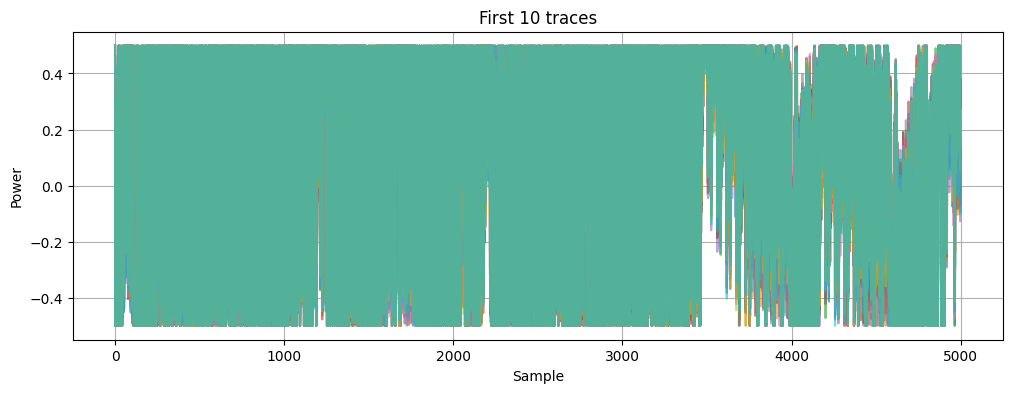

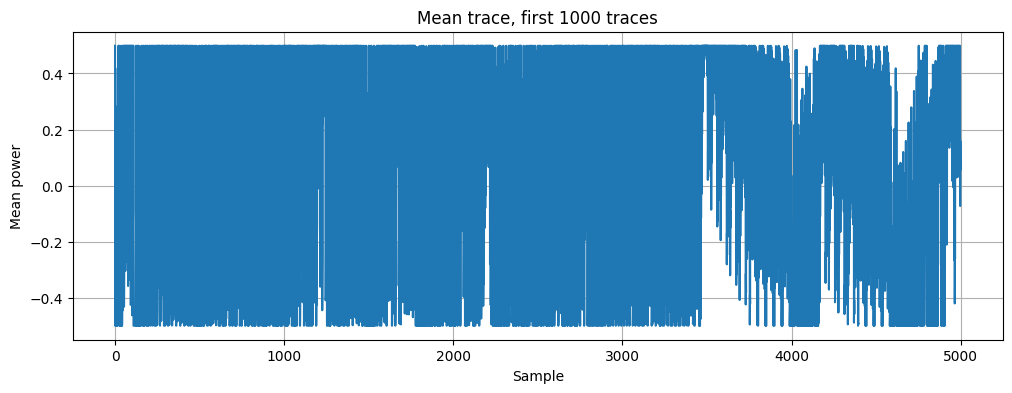

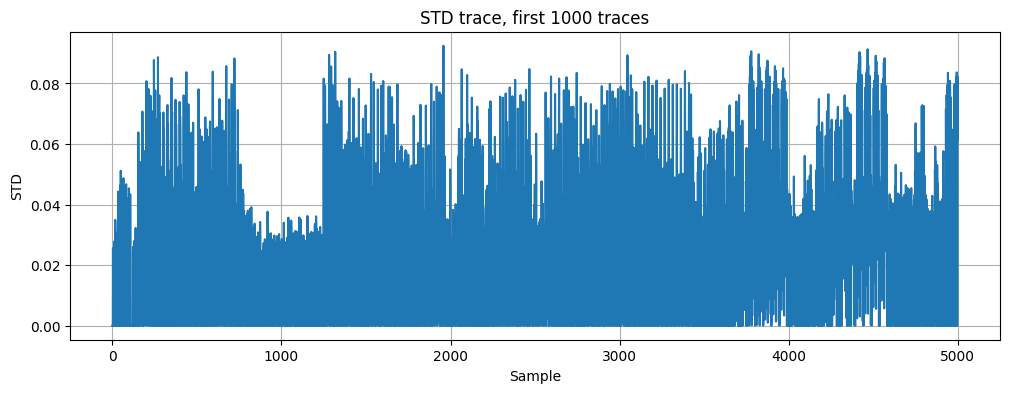

In [5]:
QC_N = min(1000, traces_mmap.shape[0])
qc_traces = np.asarray(traces_mmap[:QC_N], dtype=np.float32)

sat = ((qc_traces <= -0.49) | (qc_traces >= 0.49))

print("QC traces shape:", qc_traces.shape)
print("sample min:", qc_traces.min())
print("sample max:", qc_traces.max())
print("overall clipping fraction:", sat.mean())
print("mean clipping per trace:", sat.mean(axis=1).mean())
print("median clipping per trace:", np.median(sat.mean(axis=1)))
print("max clipping per trace:", sat.mean(axis=1).max())

mean_trace = qc_traces.mean(axis=0)
std_trace = qc_traces.std(axis=0)

plt.figure(figsize=(12, 4))
for i in range(min(10, QC_N)):
    plt.plot(qc_traces[i], alpha=0.6)
plt.title("First 10 traces")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(mean_trace)
plt.title("Mean trace, first 1000 traces")
plt.xlabel("Sample")
plt.ylabel("Mean power")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(std_trace)
plt.title("STD trace, first 1000 traces")
plt.xlabel("Sample")
plt.ylabel("STD")
plt.grid(True)
plt.show()

## 3. Analysis settings

Start with quick settings first. If the quick run works, increase `N_USE` to 30000 and use all samples.

Recommended first diagnostic run:
```python
N_USE = 5000
SAMPLE_START = 0
SAMPLE_END = 5000
SAMPLE_STRIDE = 2
```

Recommended full test on your current dataset:
```python
N_USE = 30000
SAMPLE_START = 0
SAMPLE_END = 5000
SAMPLE_STRIDE = 1
```

In [6]:
# Start with 5000 for quick diagnostic. Change to 30000 for full test.
N_USE = 30000

# Sample window.
SAMPLE_START = 0
SAMPLE_END = None     # None means use until the end
SAMPLE_STRIDE = 1     # use 1 for full sample resolution

# Test both because paper bit indexing and firmware little-endian indexing may differ.
MODES_TO_TEST = ["firmware", "paper"]

# Target bit positions.
BIT_POSITIONS = list(range(64))

print("N_USE:", N_USE)
print("SAMPLE_START:", SAMPLE_START)
print("SAMPLE_END:", SAMPLE_END)
print("SAMPLE_STRIDE:", SAMPLE_STRIDE)
print("MODES_TO_TEST:", MODES_TO_TEST)
print("number of bit positions:", len(BIT_POSITIONS))

N_USE: 30000
SAMPLE_START: 0
SAMPLE_END: None
SAMPLE_STRIDE: 1
MODES_TO_TEST: ['firmware', 'paper']
number of bit positions: 64


In [7]:
N_TOTAL, S_TOTAL = traces_mmap.shape
N_USE = min(N_USE, N_TOTAL)

if SAMPLE_END is None:
    SAMPLE_END = S_TOTAL

sample_indices = np.arange(SAMPLE_START, SAMPLE_END, SAMPLE_STRIDE)

trace_block = np.asarray(traces_mmap[:N_USE, sample_indices], dtype=np.float32)
metadata_use = metadata.iloc[:N_USE].copy().reset_index(drop=True)

print("Selected trace block shape:", trace_block.shape)
print("Selected samples:", sample_indices[0], "to", sample_indices[-1], "stride", SAMPLE_STRIDE)
print("Selected metadata shape:", metadata_use.shape)

# Center traces once for CPA efficiency.
trace_centered = trace_block - trace_block.mean(axis=0, keepdims=True)
trace_energy = np.sum(trace_centered * trace_centered, axis=0)

print("trace_centered shape:", trace_centered.shape)
print("trace_energy min/max:", trace_energy.min(), trace_energy.max())

Selected trace block shape: (30000, 5000)
Selected samples: 0 to 4999 stride 1
Selected metadata shape: (30000, 6)
trace_centered shape: (30000, 5000)
trace_energy min/max: 0.0 248.51915


## 4. Little-endian bit extraction

Your `encrypt.c` uses little-endian loading:

```c
x |= SETBYTE(bytes[i], i);
```

So this notebook first uses little-endian 64-bit word loading, matching your firmware.

In [8]:
def load64_le_from_bytes(b, offset_bytes):
    x = 0
    for i in range(8):
        x |= int(b[offset_bytes + i]) << (8 * i)
    return x

def load64_le_from_hex(hexstr, offset_bytes):
    b = bytes.fromhex(hexstr)
    return load64_le_from_bytes(b, offset_bytes)

def bit_scalar(x, i):
    return (int(x) >> (i % 64)) & 1

def bits_from_uint64_array(arr, idx):
    return ((arr >> np.uint64(idx % 64)) & np.uint64(1)).astype(np.uint8)

fixed_key_hex = metadata_use["key_hex"].iloc[0]
fixed_key = bytes.fromhex(fixed_key_hex)

K0 = load64_le_from_bytes(fixed_key, 0)
K1 = load64_le_from_bytes(fixed_key, 8)

print("fixed_key_hex:", fixed_key_hex)
print("K0 little-endian:", hex(K0))
print("K1 little-endian:", hex(K1))

fixed_key_hex: 00112233445566778899aabbccddeeff
K0 little-endian: 0x7766554433221100
K1 little-endian: 0xffeeddccbbaa9988


In [9]:
nonce_hex_list = metadata_use["nonce_hex"].astype(str).tolist()

N0 = np.array([load64_le_from_hex(nh, 0) for nh in nonce_hex_list], dtype=np.uint64)  # x3
N1 = np.array([load64_le_from_hex(nh, 8) for nh in nonce_hex_list], dtype=np.uint64)  # x4

print("N0 shape:", N0.shape)
print("N1 shape:", N1.shape)
print("First nonce:", nonce_hex_list[0])
print("First N0:", hex(int(N0[0])))
print("First N1:", hex(int(N1[0])))

N0 shape: (30000,)
N1 shape: (30000,)
First nonce: 4adb842bddfe40f59e3235161bb3fea5
First N0: 0xf540fedd2b84db4a
First N1: 0xa5feb31b1635329e


## 5. x′0 selection function

The ASCON first-round `x′0` attack uses 3 key-bit candidates, so each bit position has 8 candidates.

This notebook tests two index conventions:

```text
firmware mode: i, i+19, i+28
paper mode:    i, i+45, i+36
```

Why test both? Your firmware uses little-endian loading, while the paper’s indexing may be written in the opposite bit direction. The correct convention should give better true ranks.

In [10]:
def x0_indices(i, mode):
    if mode == "firmware":
        return [i, i + 19, i + 28]
    elif mode == "paper":
        return [i, i + 45, i + 36]
    else:
        raise ValueError("mode must be 'firmware' or 'paper'")

def true_x0_candidate(K0, i, mode):
    idxs = x0_indices(i, mode)
    c0 = bit_scalar(K0, idxs[0])
    c1 = bit_scalar(K0, idxs[1])
    c2 = bit_scalar(K0, idxs[2])
    return c0 | (c1 << 1) | (c2 << 2)

def x0_predictions_all_candidates(N0, N1, i, mode):
    # Returns P with shape (N, 8), where each column is prediction for candidate 0..7.
    idxs = x0_indices(i, mode)
    m0  = bits_from_uint64_array(N0, idxs[0])
    mp0 = bits_from_uint64_array(N1, idxs[0])
    m1  = bits_from_uint64_array(N0, idxs[1])
    mp1 = bits_from_uint64_array(N1, idxs[1])
    m2  = bits_from_uint64_array(N0, idxs[2])
    mp2 = bits_from_uint64_array(N1, idxs[2])

    P = np.zeros((len(N0), 8), dtype=np.uint8)

    for cand in range(8):
        c0 = (cand >> 0) & 1
        c1 = (cand >> 1) & 1
        c2 = (cand >> 2) & 1

        pred = np.zeros(len(N0), dtype=np.uint8)
        pred ^= (c0 & (mp0 ^ 1)) ^ m0
        pred ^= (c1 & (mp1 ^ 1)) ^ m1
        pred ^= (c2 & (mp2 ^ 1)) ^ m2

        P[:, cand] = pred

    return P

for mode in MODES_TO_TEST:
    i = 0
    print(mode, "bit", i, "true candidate:", true_x0_candidate(K0, i, mode))
    P_test = x0_predictions_all_candidates(N0, N1, i, mode)
    print("P_test shape:", P_test.shape, "candidate means:", P_test.mean(axis=0))

firmware bit 0 true candidate: 4
P_test shape: (30000, 8) candidate means: [0.49563333 0.4992     0.5014     0.4993     0.49893333 0.50243333
 0.4975     0.4996    ]
paper bit 0 true candidate: 0
P_test shape: (30000, 8) candidate means: [0.49813333 0.49623333 0.50033333 0.50196667 0.50093333 0.49776667
 0.49973333 0.5001    ]


## 6. CPA and DPA scoring

CPA computes Pearson correlation between the binary prediction and each sample point.

DPA computes the absolute difference between the mean trace of prediction group 1 and group 0.

In [11]:
def score_cpa_all_candidates(P, trace_centered, trace_energy):
    P = P.astype(np.float32)
    P_centered = P - P.mean(axis=0, keepdims=True)

    p_energy = np.sum(P_centered * P_centered, axis=0)  # C
    numerator = P_centered.T @ trace_centered           # C x S
    denom = np.sqrt(p_energy[:, None] * trace_energy[None, :]) + 1e-12

    corr = numerator / denom
    abs_corr = np.abs(corr)

    best_samples = np.argmax(abs_corr, axis=1)
    scores = abs_corr[np.arange(P.shape[1]), best_samples]
    best_corrs = corr[np.arange(P.shape[1]), best_samples]

    return scores, best_samples, best_corrs

def score_dpa_all_candidates(P, trace_block):
    P = P.astype(np.float32)
    N = P.shape[0]

    count1 = P.sum(axis=0)
    count0 = N - count1

    count1_safe = np.maximum(count1, 1)
    count0_safe = np.maximum(count0, 1)

    sum1 = P.T @ trace_block
    total = trace_block.sum(axis=0, keepdims=True)
    sum0 = total - sum1

    mean1 = sum1 / count1_safe[:, None]
    mean0 = sum0 / count0_safe[:, None]

    diff = mean1 - mean0
    abs_diff = np.abs(diff)

    best_samples = np.argmax(abs_diff, axis=1)
    scores = abs_diff[np.arange(P.shape[1]), best_samples]
    best_diffs = diff[np.arange(P.shape[1]), best_samples]

    return scores, best_samples, best_diffs

## 7. Run x′0 CPA/DPA

This cell may take time. Start with `N_USE = 5000` and `SAMPLE_STRIDE = 2`. Then increase to full settings if the code runs properly.

In [12]:
all_results = []

for mode in MODES_TO_TEST:
    print("\nRunning mode:", mode)

    for i in BIT_POSITIONS:
        P = x0_predictions_all_candidates(N0, N1, i, mode)
        true_cand = true_x0_candidate(K0, i, mode)

        # CPA
        cpa_scores, cpa_best_samples_local, cpa_signed = score_cpa_all_candidates(P, trace_centered, trace_energy)
        cpa_order = np.argsort(cpa_scores)[::-1]
        cpa_true_rank = int(np.where(cpa_order == true_cand)[0][0]) + 1
        cpa_best_cand = int(cpa_order[0])

        all_results.append({
            "target": "x0_prime",
            "mode": mode,
            "method": "CPA",
            "bit_i": i,
            "true_candidate": int(true_cand),
            "best_candidate": int(cpa_best_cand),
            "true_rank": int(cpa_true_rank),
            "best_score": float(cpa_scores[cpa_best_cand]),
            "true_score": float(cpa_scores[true_cand]),
            "best_sample_local": int(cpa_best_samples_local[cpa_best_cand]),
            "true_best_sample_local": int(cpa_best_samples_local[true_cand]),
            "best_sample_original": int(sample_indices[cpa_best_samples_local[cpa_best_cand]]),
            "true_best_sample_original": int(sample_indices[cpa_best_samples_local[true_cand]]),
            "candidate_scores": cpa_scores.tolist()
        })

        # DPA
        dpa_scores, dpa_best_samples_local, dpa_signed = score_dpa_all_candidates(P, trace_block)
        dpa_order = np.argsort(dpa_scores)[::-1]
        dpa_true_rank = int(np.where(dpa_order == true_cand)[0][0]) + 1
        dpa_best_cand = int(dpa_order[0])

        all_results.append({
            "target": "x0_prime",
            "mode": mode,
            "method": "DPA",
            "bit_i": i,
            "true_candidate": int(true_cand),
            "best_candidate": int(dpa_best_cand),
            "true_rank": int(dpa_true_rank),
            "best_score": float(dpa_scores[dpa_best_cand]),
            "true_score": float(dpa_scores[true_cand]),
            "best_sample_local": int(dpa_best_samples_local[dpa_best_cand]),
            "true_best_sample_local": int(dpa_best_samples_local[true_cand]),
            "best_sample_original": int(sample_indices[dpa_best_samples_local[dpa_best_cand]]),
            "true_best_sample_original": int(sample_indices[dpa_best_samples_local[true_cand]]),
            "candidate_scores": dpa_scores.tolist()
        })

        if i % 8 == 0:
            print(f"  bit {i:02d} done")

results_df = pd.DataFrame(all_results)
print("\nDone. results shape:", results_df.shape)
display(results_df.head())


Running mode: firmware
  bit 00 done
  bit 08 done
  bit 16 done
  bit 24 done
  bit 32 done
  bit 40 done
  bit 48 done
  bit 56 done

Running mode: paper
  bit 00 done
  bit 08 done
  bit 16 done
  bit 24 done
  bit 32 done
  bit 40 done
  bit 48 done
  bit 56 done

Done. results shape: (256, 14)


,target,mode,method,bit_i,true_candidate,best_candidate,true_rank,best_score,true_score,best_sample_local,true_best_sample_local,best_sample_original,true_best_sample_original,candidate_scores
0,x0_prime,firmware,CPA,0,4,4,1,0.202318,0.202318,4808,4808,4808,4808,"[0.021512875333428383, 0.017295585945248604, 0..."
1,x0_prime,firmware,DPA,0,4,4,1,0.017874,0.017874,4804,4804,4804,4804,"[0.003039167495444417, 0.002236977219581604, 0..."
2,x0_prime,firmware,CPA,1,4,4,1,0.158257,0.158257,4804,4804,4804,4804,"[0.020098330453038216, 0.02140791341662407, 0...."
3,x0_prime,firmware,DPA,1,4,4,1,0.015477,0.015477,4804,4804,4804,4804,"[0.0024961531162261963, 0.0028026998043060303,..."
4,x0_prime,firmware,CPA,2,2,2,1,0.228760,0.228760,4808,4808,4808,4808,"[0.02185133658349514, 0.021151652559638023, 0...."


## 8. Summarise ranks

Random guessing among 8 candidates has approximately:
- Rank-1 count ≈ 8 / 64
- Average rank ≈ 4.5

Useful leakage should show:
- Rank-1 clearly above 8 / 64
- Average true rank clearly below 4.5

In [13]:
summary_rows = []

for (mode, method), df in results_df.groupby(["mode", "method"]):
    rank1 = int((df["true_rank"] == 1).sum())
    rank2 = int((df["true_rank"] <= 2).sum())
    rank4 = int((df["true_rank"] <= 4).sum())
    avg_rank = float(df["true_rank"].mean())
    med_rank = float(df["true_rank"].median())

    summary_rows.append({
        "mode": mode,
        "method": method,
        "rank1_count_out_of_64": rank1,
        "rank_le_2_out_of_64": rank2,
        "rank_le_4_out_of_64": rank4,
        "average_true_rank": avg_rank,
        "median_true_rank": med_rank
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["mode", "method"])
display(summary_df)

print("\nRank distribution:")
display(results_df.groupby(["mode", "method"])["true_rank"].value_counts().sort_index())

,mode,method,rank1_count_out_of_64,rank_le_2_out_of_64,rank_le_4_out_of_64,average_true_rank,median_true_rank
0,firmware,CPA,64,64,64,1.000000,1.0
1,firmware,DPA,64,64,64,1.000000,1.0
2,paper,CPA,8,13,34,4.437500,4.0
3,paper,DPA,6,12,32,4.796875,4.5



Rank distribution:


mode      method  true_rank
firmware  CPA     1            64
          DPA     1            64
paper     CPA     1             8
                  2             5
                  3             7
                  4            14
                  5            11
                  6             4
                  7            10
                  8             5
          DPA     1             6
                  2             6
                  3             8
                  4            12
                  5             5
                  6             7
                  7            10
                  8            10
Name: count, dtype: int64

In [14]:
for mode in MODES_TO_TEST:
    for method in ["CPA", "DPA"]:
        df = results_df[(results_df["mode"] == mode) & (results_df["method"] == method)].copy()
        print("\n", "=" * 80)
        print("Mode:", mode, "| Method:", method)
        print("Rank-1 positions:")
        display(df[df["true_rank"] == 1][["bit_i", "true_candidate", "best_candidate", "true_rank", "best_score", "true_score", "best_sample_original"]].head(20))

        print("Worst positions:")
        display(df.sort_values("true_rank", ascending=False)[["bit_i", "true_candidate", "best_candidate", "true_rank", "best_score", "true_score", "best_sample_original"]].head(10))


Mode: firmware | Method: CPA
Rank-1 positions:


,bit_i,true_candidate,best_candidate,true_rank,best_score,true_score,best_sample_original
0,0,4,4,1,0.202318,0.202318,4808
2,1,4,4,1,0.158257,0.158257,4804
4,2,2,2,1,0.228760,0.228760,4808
6,3,0,0,1,0.237110,0.237110,4808
8,4,0,0,1,0.178377,0.178377,4808
10,5,2,2,1,0.181701,0.181701,4808
12,6,6,6,1,0.188042,0.188042,4808
14,7,0,0,1,0.212357,0.212357,4808
16,8,1,1,1,0.265286,0.265286,4816
18,9,2,2,1,0.226234,0.226234,4811


Worst positions:


,bit_i,true_candidate,best_candidate,true_rank,best_score,true_score,best_sample_original
0,0,4,4,1,0.202318,0.202318,4808
2,1,4,4,1,0.158257,0.158257,4804
68,34,7,7,1,0.258805,0.258805,4839
70,35,2,2,1,0.271084,0.271084,4839
72,36,0,0,1,0.211391,0.211391,4839
74,37,2,2,1,0.214552,0.214552,4839
76,38,3,3,1,0.250273,0.250273,4839
78,39,2,2,1,0.242491,0.242491,4835
80,40,1,1,1,0.309334,0.309334,4848
82,41,2,2,1,0.259015,0.259015,4848



Mode: firmware | Method: DPA
Rank-1 positions:


...

,bit_i,true_candidate,best_candidate,true_rank,best_score,true_score,best_sample_original
168,20,4,6,8,0.021232,0.018131,2510
238,55,0,3,8,0.023493,0.018263,2795
218,45,4,0,8,0.023336,0.017487,4455
186,29,1,2,8,0.021826,0.016450,4888
178,25,5,6,8,0.023809,0.017836,1109
128,0,0,3,7,0.023756,0.018400,2622
228,50,1,4,7,0.022752,0.019306,1407
220,46,1,7,7,0.024783,0.020014,2445
206,39,0,5,7,0.023205,0.019269,1264
202,37,0,7,7,0.022686,0.019630,685



Mode: paper | Method: DPA
Rank-1 positions:


,bit_i,true_candidate,best_candidate,true_rank,best_score,true_score,best_sample_original
143,7,0,0,1,0.003098,0.003098,3826
171,21,5,5,1,0.003074,0.003074,377
195,33,0,0,1,0.003298,0.003298,2350
209,40,7,7,1,0.003258,0.003258,1934
229,50,1,1,1,0.003154,0.003154,594
249,60,1,1,1,0.002864,0.002864,3834


Worst positions:


,bit_i,true_candidate,best_candidate,true_rank,best_score,true_score,best_sample_original
207,39,0,5,8,0.003011,0.002034,4517
201,36,6,7,8,0.003010,0.001923,4285
179,25,5,3,8,0.003596,0.002298,3982
227,49,5,2,8,0.002943,0.002094,1282
181,26,4,2,8,0.003070,0.001938,4466
187,29,1,5,8,0.003224,0.002159,1282
141,6,4,7,8,0.002990,0.002099,1250
153,12,3,4,8,0.003198,0.002032,594
167,19,0,7,8,0.003654,0.002313,1330
131,1,2,4,8,0.003067,0.002180,438


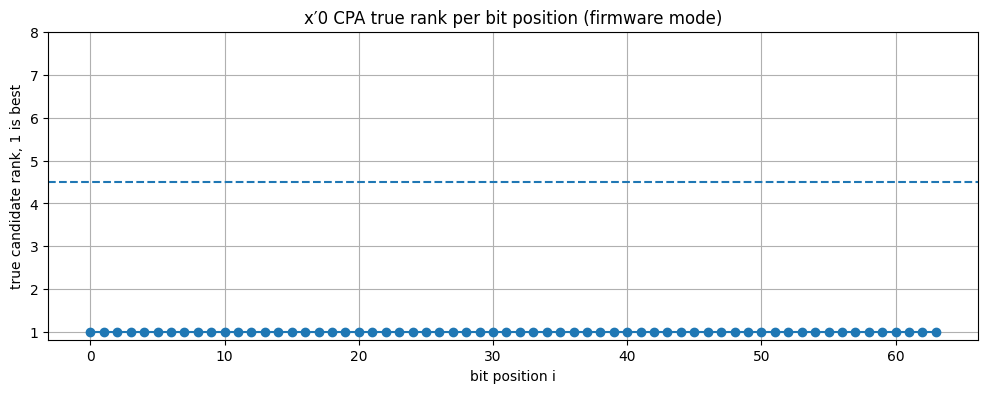

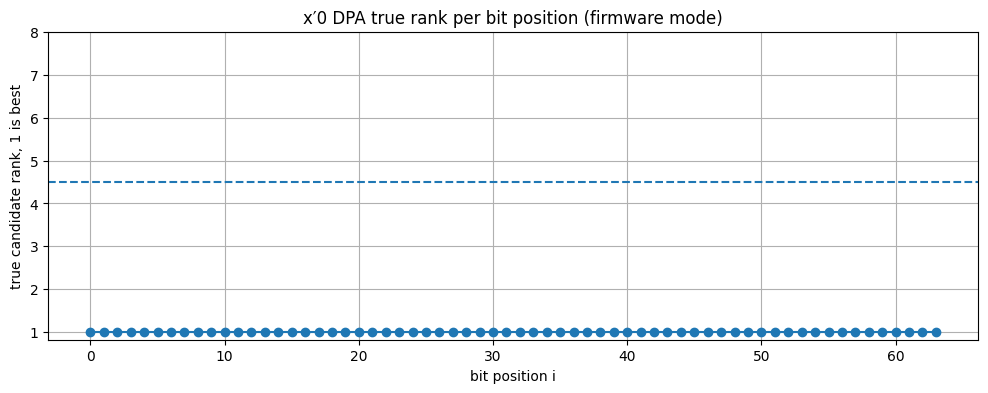

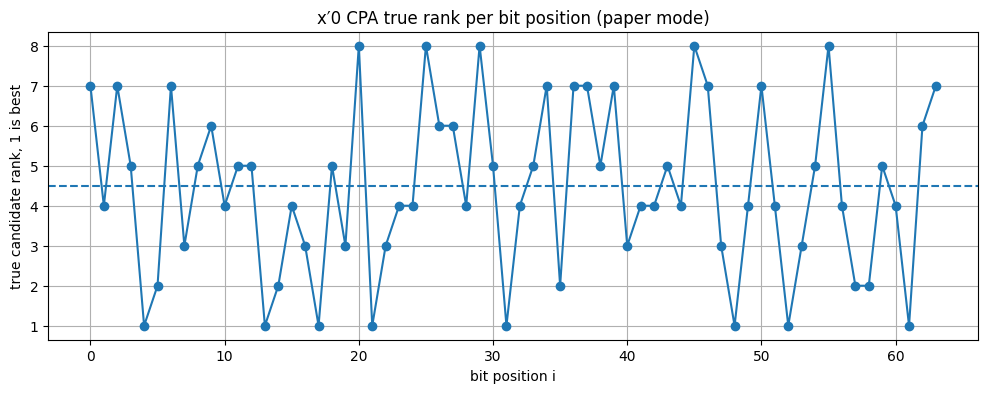

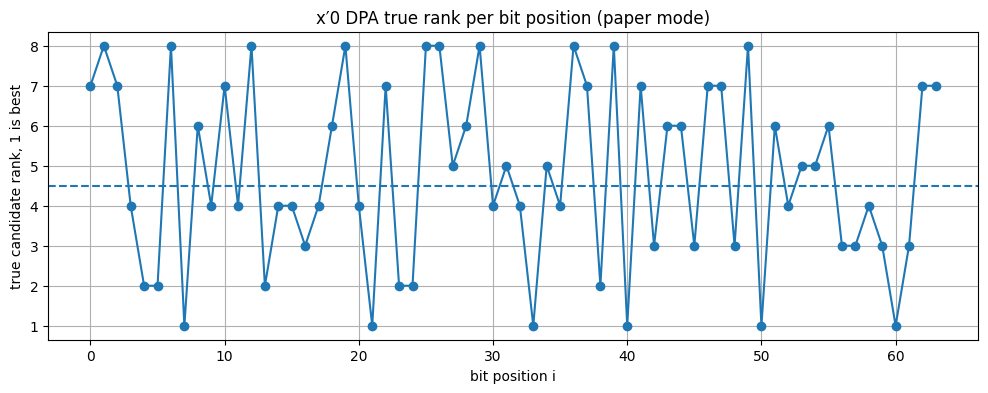

In [15]:
for mode in MODES_TO_TEST:
    for method in ["CPA", "DPA"]:
        df = results_df[(results_df["mode"] == mode) & (results_df["method"] == method)].sort_values("bit_i")

        plt.figure(figsize=(12, 4))
        plt.plot(df["bit_i"], df["true_rank"], marker="o")
        plt.axhline(4.5, linestyle="--")
        plt.title(f"x′0 {method} true rank per bit position ({mode} mode)")
        plt.xlabel("bit position i")
        plt.ylabel("true candidate rank, 1 is best")
        plt.yticks(range(1, 9))
        plt.grid(True)
        plt.show()

## 9. Save results

In [16]:
suffix = f"N{N_USE}_samples{SAMPLE_START}_{SAMPLE_END}_stride{SAMPLE_STRIDE}"

results_csv = RUN_DIR / f"x0_bit_cpa_dpa_results_{suffix}.csv"
summary_csv = RUN_DIR / f"x0_bit_cpa_dpa_summary_{suffix}.csv"

results_df.to_csv(results_csv, index=False)
summary_df.to_csv(summary_csv, index=False)

print("Saved results:", results_csv)
print("Saved summary:", summary_csv)

Saved results: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_20260612_051138\x0_bit_cpa_dpa_results_N30000_samples0_5000_stride1.csv
Saved summary: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_20260612_051138\x0_bit_cpa_dpa_summary_N30000_samples0_5000_stride1.csv


## 10. Interpretation guide

Use this guide:

```text
Rank-1 ≈ 8/64 and average rank ≈ 4.5
→ close to random guessing among 8 candidates. Dataset likely not useful or indexing/model mismatch.

Rank-1 clearly above 8/64 and average rank clearly below 4.5
→ useful x′0 leakage exists.

CPA/DPA works in firmware mode but not paper mode
→ your firmware little-endian indexing is likely the right convention.

CPA/DPA works in paper mode but not firmware mode
→ paper-style reverse indexing may match better.

Both fail
→ likely caused by clipping, wrong leakage model, wrong bit indexing, or the software implementation leaking at different operation points.
```

Because your current dataset has high clipping, failure is not conclusive. If this test fails, recollect with:

```python
scope.gain.db = 30
scope.adc.samples = 12000
```